# Pareto Front Analysis

Notebook này chọn 6 instance tiêu biểu gồm 3 nhóm C/R/RC cho data100 và 3 nhóm C/R/RC cho data200, sau đó vẽ Pareto front theo hai mục tiêu `makespan` và `carbon`. Các hình được lưu dạng PDF trong thư mục `pareto_front_analysis`.

In [49]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG
OUTPUT_DIR = Path("pareto_front_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

ALGOS = [
    "NSGA_II",
    "MOEA_D",
    "PFG_MOEA",
    "PFG_MOEA_D",
    "NSGA_III",
    "ALNSMO",
]

BASE_ALGO = "PFG_MOEA_D"

COLORS = {
    "NSGA_II": "#ff8c00",    # bright orange
    "MOEA_D": "#0066ff",     # bright blue
    "PFG_MOEA": "#00c853",   # bright green
    "PFG_MOEA_D": "#ff1744", # bright red
    "NSGA_III": "#8e24aa",   # bright purple
    "ALNSMO": "#ffd600",     # bright yellow
}


DATASETS = {
    "data100": {
        "summary_results": "summary_results_data100_new_ver2.xlsx",
        "result_root_5algo": "result_instance_5algo_with_stop_time_56",
        "result_root_2algo": "result_instance100_2algo_NSGA3_ALNSMO",
    },
    "data200": {
        "summary_results": "summary_results_data200_new_ver2.xlsx",
        "result_root_5algo": "result_instance_5algo_with_stop_time_56_data200",
        "result_root_2algo": "result_instance200_2algo_NSGA3_ALNSMO/result_instance200_2algo_NSGA3_ALNSMO",
    },
}

RESULT_ROOT_BY_ALGO = {
    dataset_name: {
        "NSGA_II": cfg["result_root_5algo"],
        "MOEA_D": cfg["result_root_5algo"],
        "PFG_MOEA": cfg["result_root_5algo"],
        "PFG_MOEA_D": cfg["result_root_5algo"],
        "NSGA_III": cfg["result_root_2algo"],
        "ALNSMO": cfg["result_root_2algo"],
    }
    for dataset_name, cfg in DATASETS.items()
}


In [50]:
# HELPERS
def get_group(instance_name):
    name = str(instance_name).upper()

    if "RC" in name:
        return "RC"
    if re.search(r"H\d+C", name):
        return "C"
    if re.search(r"H\d+R", name):
        return "R"

    return None


def to_folder_name(instance_name):
    instance_name = str(instance_name)
    if instance_name.startswith("result_"):
        return instance_name
    return f"result_{instance_name}"


def pareto_file(dataset_name, folder, algo):
    root = RESULT_ROOT_BY_ALGO[dataset_name][algo]
    return os.path.join(root, folder, f"pareto_{algo}.csv")


def load_pf(dataset_name, folder, algo):
    file_path = pareto_file(dataset_name, folder, algo)
    df = pd.read_csv(file_path)
    return df[["makespan", "carbon"]].drop_duplicates().values


def get_non_dominated(points):
    points = np.unique(points, axis=0)
    n = len(points)
    is_dominated = np.zeros(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                is_dominated[i] = True
                break

    return points[~is_dominated]


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))


In [51]:
# SELECT 6 REPRESENTATIVE INSTANCES
def load_metric_sheets(summary_file):
    return {
        "HV": pd.read_excel(summary_file, sheet_name="HV"),
        "IGD": pd.read_excel(summary_file, sheet_name="IGD"),
        "Makespan": pd.read_excel(summary_file, sheet_name="Makespan"),
        "CO2": pd.read_excel(summary_file, sheet_name="CO2"),
    }


def choose_instances(dataset_name, cfg):
    sheets = load_metric_sheets(cfg["summary_results"])
    base = sheets["HV"][["Instance"]].copy()
    base["Dataset"] = dataset_name
    base["Group"] = base["Instance"].apply(get_group)

    # Chọn instance mà PFG_MOEA_D có rank tổng hợp tốt nhất:
    # HV càng cao càng tốt; IGD, Makespan, CO2 càng thấp càng tốt.
    base["rank_hv"] = sheets["HV"][BASE_ALGO].rank(ascending=False, method="min")
    base["rank_igd"] = sheets["IGD"][BASE_ALGO].rank(ascending=True, method="min")
    base["rank_makespan"] = sheets["Makespan"][BASE_ALGO].rank(ascending=True, method="min")
    base["rank_co2"] = sheets["CO2"][BASE_ALGO].rank(ascending=True, method="min")
    base["score"] = base[["rank_hv", "rank_igd", "rank_makespan", "rank_co2"]].mean(axis=1)

    selected = []
    for group in ["C", "R", "RC"]:
        candidates = base[base["Group"] == group].sort_values("score")
        if candidates.empty:
            continue
        selected.append(candidates.iloc[0])

    return pd.DataFrame(selected)


selected_instances = pd.concat(
    [choose_instances(dataset_name, cfg) for dataset_name, cfg in DATASETS.items()],
    ignore_index=True,
)

selected_instances[["Dataset", "Group", "Instance", "score", "rank_hv", "rank_igd", "rank_makespan", "rank_co2"]]


,Dataset,Group,Instance,score,rank_hv,rank_igd,rank_makespan,rank_co2
0,data100,C,h100c104,15.75,6.0,18.0,1.0,38.0
1,data100,R,h100r208,12.25,2.0,34.0,2.0,11.0
2,data100,RC,h100rc202,14.25,1.0,7.0,25.0,24.0
3,data200,C,h200C1_2_4,11.50,7.0,11.0,1.0,27.0
4,data200,R,h200R2_2_8,11.25,22.0,14.0,2.0,7.0
5,data200,RC,h200RC1_2_10,20.75,35.0,29.0,17.0,2.0


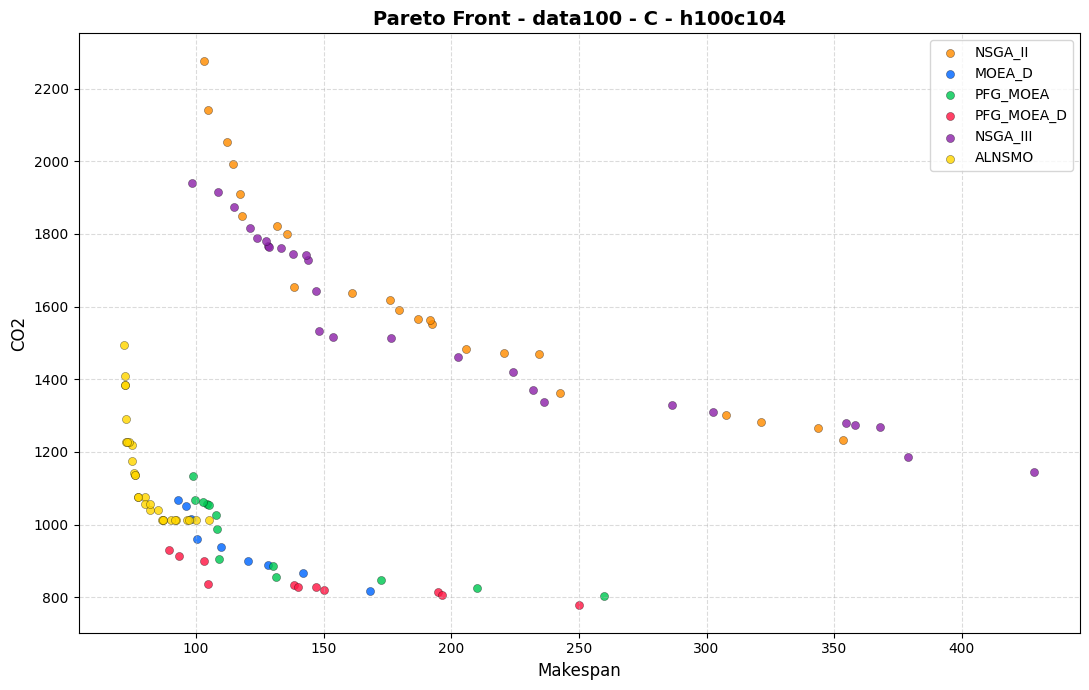

Saved: pareto_front_analysis\pareto_data100_C_h100c104.pdf


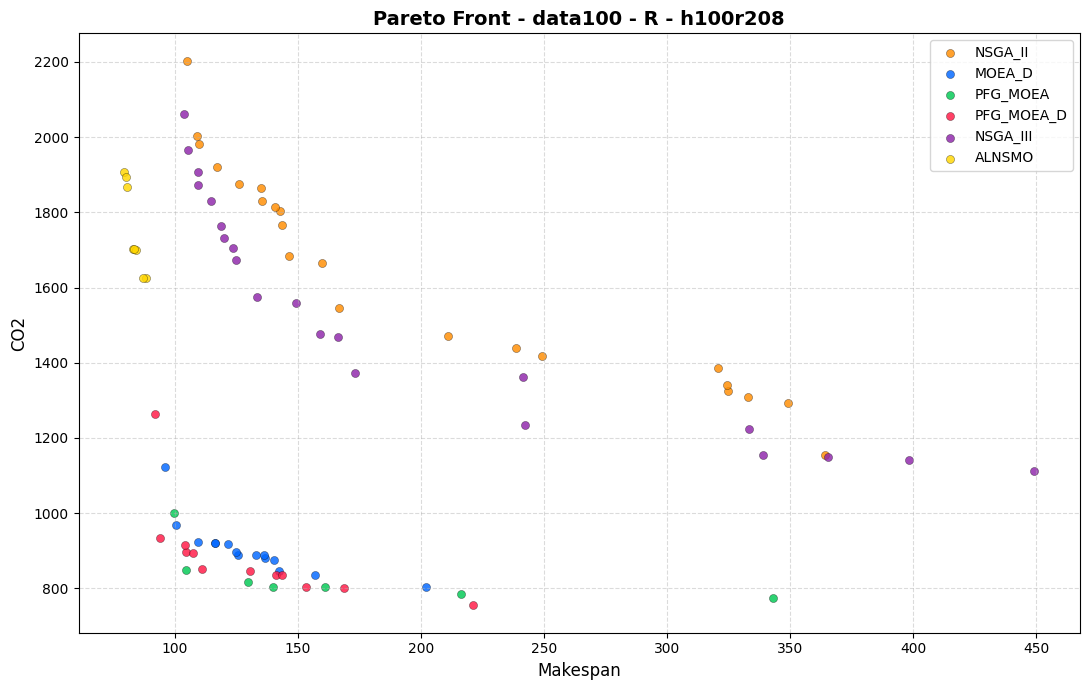

Saved: pareto_front_analysis\pareto_data100_R_h100r208.pdf


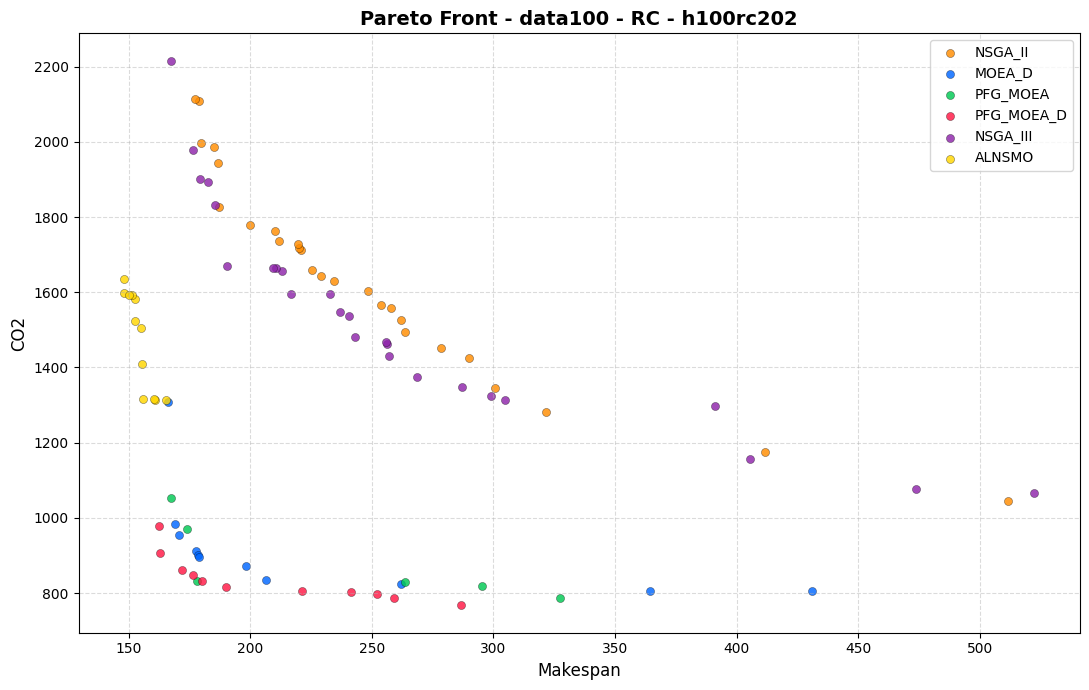

Saved: pareto_front_analysis\pareto_data100_RC_h100rc202.pdf


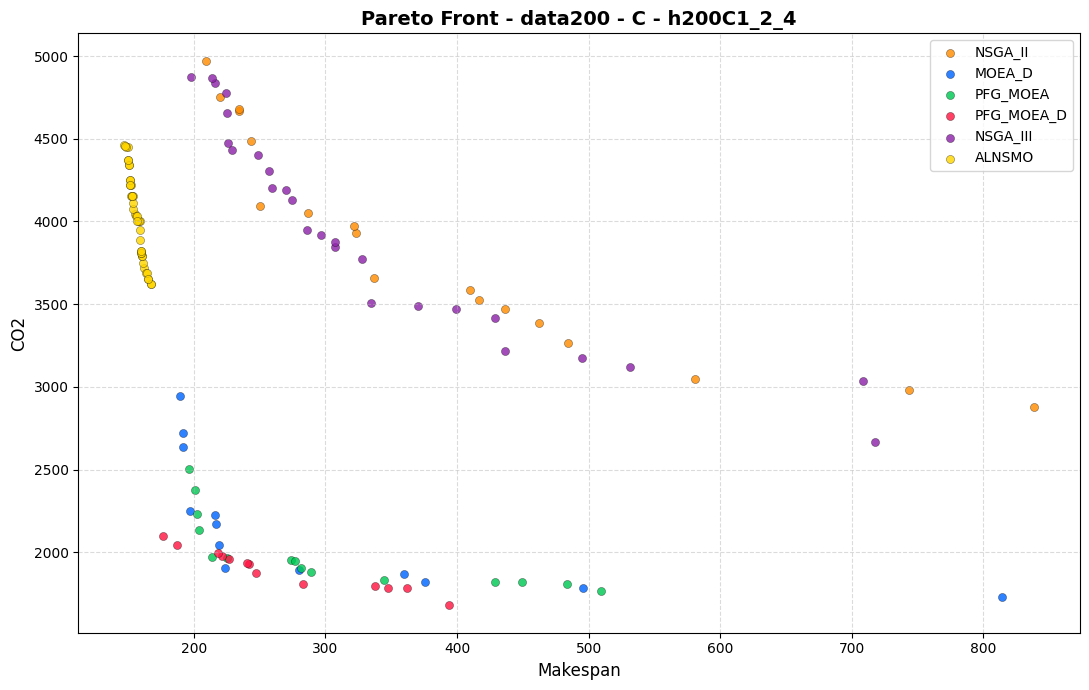

Saved: pareto_front_analysis\pareto_data200_C_h200C1_2_4.pdf


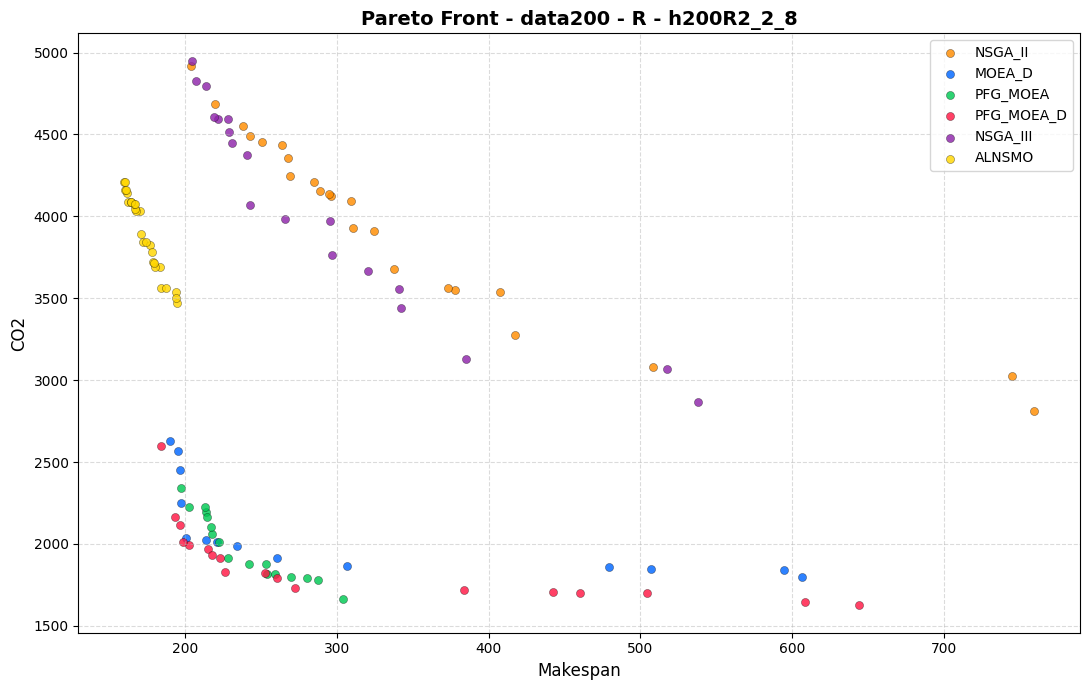

Saved: pareto_front_analysis\pareto_data200_R_h200R2_2_8.pdf


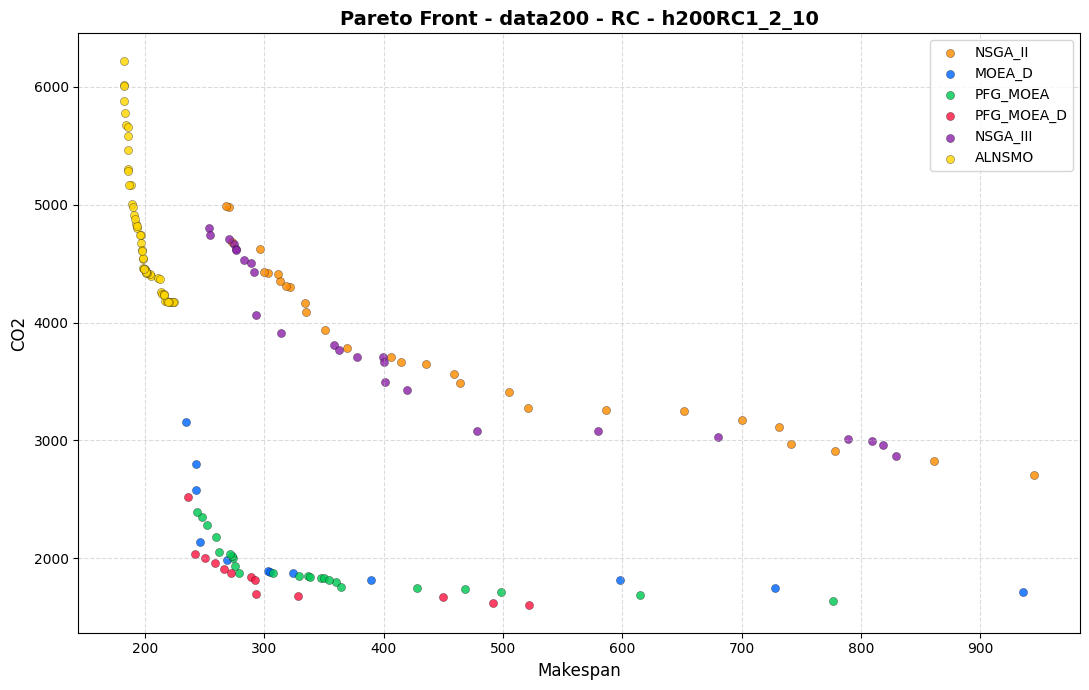

Saved: pareto_front_analysis\pareto_data200_RC_h200RC1_2_10.pdf


[WindowsPath('pareto_front_analysis/pareto_data100_C_h100c104.pdf'),
 WindowsPath('pareto_front_analysis/pareto_data100_R_h100r208.pdf'),
 WindowsPath('pareto_front_analysis/pareto_data100_RC_h100rc202.pdf'),
 WindowsPath('pareto_front_analysis/pareto_data200_C_h200C1_2_4.pdf'),
 WindowsPath('pareto_front_analysis/pareto_data200_R_h200R2_2_8.pdf'),
 WindowsPath('pareto_front_analysis/pareto_data200_RC_h200RC1_2_10.pdf')]

In [52]:
# PLOT AND SAVE 6 PARETO FRONT FIGURES
def plot_pareto_front(dataset_name, group, instance_name):
    folder = to_folder_name(instance_name)
    pf_dict = {}
    missing = []

    for algo in ALGOS:
        file_path = pareto_file(dataset_name, folder, algo)
        if os.path.exists(file_path):
            pf_dict[algo] = load_pf(dataset_name, folder, algo)
        else:
            missing.append(algo)

    if missing:
        print(f"Skip {dataset_name} {instance_name}: missing {missing}")
        return None


    plt.figure(figsize=(11, 7))

    for algo in ALGOS:
        pf = pf_dict[algo]
        plt.scatter(
            pf[:, 0],
            pf[:, 1],
            s=34,
            label=algo,
            color=COLORS[algo],
            marker="o",
            alpha=0.82,
            edgecolors="black",
            linewidths=0.25,
        )


    plt.title(f"Pareto Front - {dataset_name} - {group} - {instance_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Makespan", fontsize=12)
    plt.ylabel("CO2", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.45)
    plt.legend(fontsize=10)
    plt.tight_layout()

    output_file = OUTPUT_DIR / f"pareto_{dataset_name}_{group}_{safe_filename(instance_name)}.pdf"
    plt.savefig(output_file, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_file}")
    return output_file


saved_files = []
for _, row in selected_instances.iterrows():
    output_file = plot_pareto_front(row["Dataset"], row["Group"], row["Instance"])
    if output_file is not None:
        saved_files.append(output_file)

saved_files
